## Descripción:

Este notebook analiza y transforma el historial de solicitudes anteriores de crédito. El objetivo es pasar de un registro por solicitud previa a un conjunto de variables agregadas por cliente (`SK_ID_CURR`) que describan comportamiento histórico, montos solicitados/aprobados, motivos de rechazo, tipo de producto y condiciones asociadas a aprobaciones.


In [1]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path('../../data')
df = pd.read_parquet(DATA_PATH/'previous_application.parquet')

## Limpieza inicial de solicitudes previas

Este bloque aplica dos reglas de depuración:

1. Conserva únicamente el último registro válido de cada aplicación anterior (`FLAG_LAST_APPL_PER_CONTRACT == "Y"`).
2. Elimina columnas con 90% o más de valores nulos.

Quedarse con el último registro válido reduce duplicidades o versiones intermedias de una misma solicitud. Además, eliminar columnas extremadamente incompletas evita introducir ruido, baja cobertura y posibles problemas de imputación en etapas posteriores.


In [ ]:
# Reglas de limpieza iniciales

# 1. Nos quedamos solo con el ultimo registro valido de cada aplicacion
df = (
    df[df["FLAG_LAST_APPL_PER_CONTRACT"].eq("Y")]
    .drop(columns=["FLAG_LAST_APPL_PER_CONTRACT"])
)

# 2. Eliminamos columnas donde el 90% o mas de sus valores sean nulos
null_ratio = df.isna().mean()
cols_to_drop = null_ratio[null_ratio >= 0.90].index.tolist()
print(f"Columnas eliminadas ({len(cols_to_drop)}):", cols_to_drop)
df = df.drop(columns=cols_to_drop)

Columnas eliminadas (2): ['RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED']


## Auditoría de variables monetarias

Aquí se revisan las columnas de montos principales (`AMT_APPLICATION`, `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_DOWN_PAYMENT`, `AMT_GOODS_PRICE`) por estado de solicitud. Para cada variable se calculan conteos de nulos, ceros y valores positivos, y luego se grafican distribuciones mediante boxplots.

Antes de crear features monetarias es necesario validar si los ceros o nulos representan casos reales, estados específicos del proceso o datos no informativos. La revisión por estado ayuda a decidir qué registros deben conservarse y qué filtros son razonables.



AMT_APPLICATION


,total,nulos,ceros,positivos,pct_nulos,pct_ceros,pct_positivos
NAME_CONTRACT_STATUS,,,,,,,
Approved,1036781,0,45304,991477,0.0,0.043697,0.956303
Canceled,316317,0,305576,10741,0.0,0.966044,0.033956
Refused,282205,0,35989,246216,0.0,0.127528,0.872472
Unused offer,26436,0,494,25942,0.0,0.018687,0.981313



AMT_CREDIT


,total,nulos,ceros,positivos,pct_nulos,pct_ceros,pct_positivos
NAME_CONTRACT_STATUS,,,,,,,
Approved,1036781,1,1551,1035229,9.645238e-07,0.001496,0.998503
Canceled,316317,0,305566,10751,0.000000e+00,0.966012,0.033988
Refused,282205,0,29155,253050,0.000000e+00,0.103311,0.896689
Unused offer,26436,0,492,25944,0.000000e+00,0.018611,0.981389



AMT_ANNUITY


...


AMT_DOWN_PAYMENT


,total,nulos,ceros,positivos,pct_nulos,pct_ceros,pct_positivos
NAME_CONTRACT_STATUS,,,,,,,
Approved,1036781,374400,294579,367800,0.361118,0.284128,0.354752
Canceled,316317,315674,489,154,0.997967,0.001546,0.000487
Refused,282205,194854,50793,36558,0.690470,0.179986,0.129544
Unused offer,26436,2442,23992,2,0.092374,0.907550,0.000076



AMT_GOODS_PRICE


,total,nulos,ceros,positivos,pct_nulos,pct_ceros,pct_positivos
NAME_CONTRACT_STATUS,,,,,,,
Approved,1036781,42835,2469,991477,0.041315,0.002381,0.956303
Canceled,316317,305568,8,10741,0.966018,0.000025,0.033956
Refused,282205,32094,3895,246216,0.113726,0.013802,0.872472
Unused offer,26436,5,489,25942,0.000189,0.018498,0.981313


<Figure size 900x400 with 0 Axes>

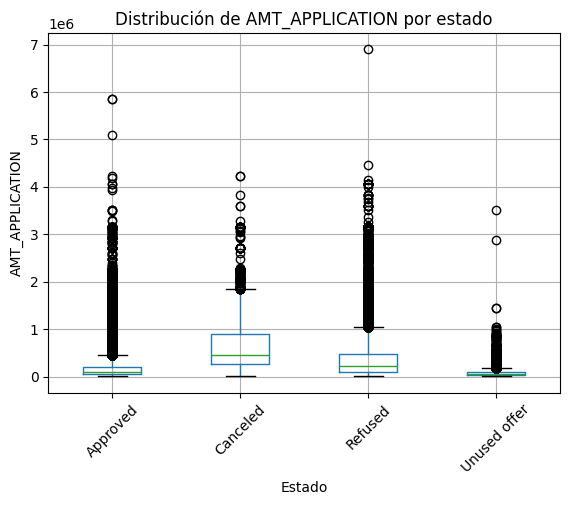

<Figure size 900x400 with 0 Axes>

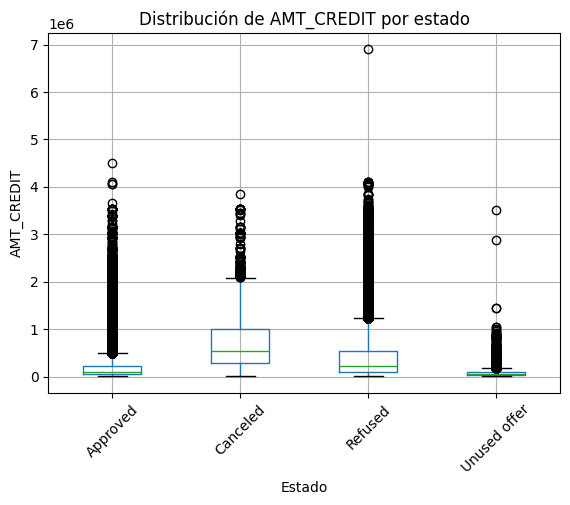

<Figure size 900x400 with 0 Axes>

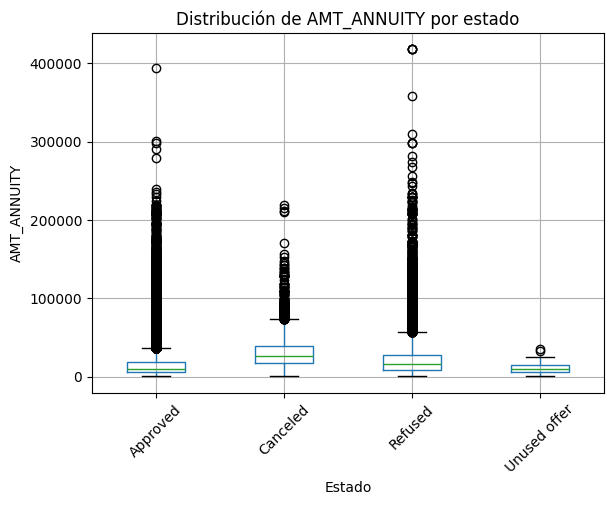

<Figure size 900x400 with 0 Axes>

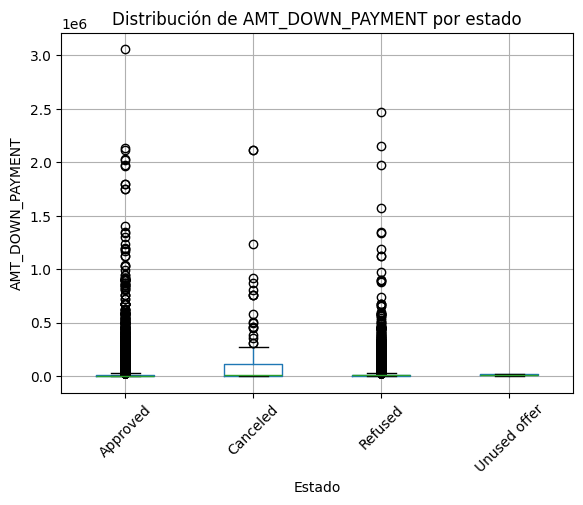

<Figure size 900x400 with 0 Axes>

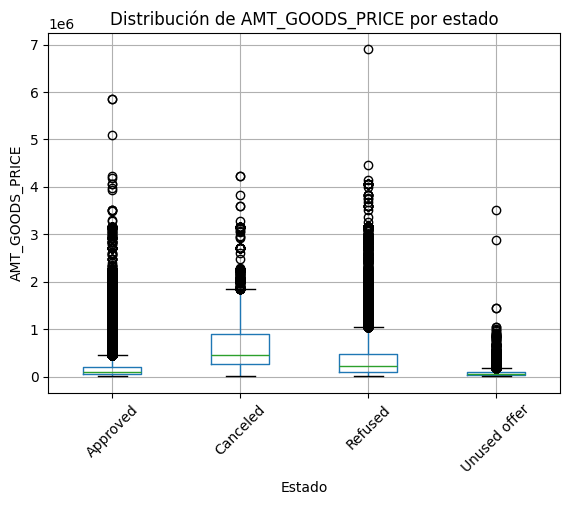

In [3]:
amount_cols = [
    "AMT_APPLICATION",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_DOWN_PAYMENT",
    "AMT_GOODS_PRICE"
]

status_col = "NAME_CONTRACT_STATUS"

for col in amount_cols:
    result = (
        df.groupby(status_col)
          .agg(
              total=(col, "size"),
              nulos=(col, lambda x: x.isna().sum()),
              ceros=(col, lambda x: (x == 0).sum()),
              positivos=(col, lambda x: (x > 0).sum())
          )
    )

    result["pct_nulos"] = result["nulos"] / result["total"]
    result["pct_ceros"] = result["ceros"] / result["total"]
    result["pct_positivos"] = result["positivos"] / result["total"]

    print(f"\n{col}")
    display(result)

import matplotlib.pyplot as plt

for col in amount_cols:
    data = df[[status_col, col]].dropna()
    data = data[data[col] > 0]

    plt.figure(figsize=(9, 4))
    data.boxplot(column=col, by=status_col, rot=45)
    plt.title(f"Distribución de {col} por estado")
    plt.suptitle("")
    plt.xlabel("Estado")
    plt.ylabel(col)
    plt.show()

## Depuración de créditos aprobados con montos inválidos

Este bloque elimina solicitudes aprobadas donde `AMT_CREDIT` o `AMT_ANNUITY` están nulos o son menores o iguales a cero.

En una solicitud aprobada se espera que exista un monto de crédito y una anualidad válidos. Mantener aprobaciones sin estos datos podría distorsionar promedios, ratios y conclusiones sobre el comportamiento crediticio aprobado.


In [ ]:
# En los creditos aprobados, no deberían el monto del credito o la anualidad ser nulos o menores o iguales a cero.
mask_bad_approved = (
    df["NAME_CONTRACT_STATUS"].eq("Approved") &
    (
        df["AMT_CREDIT"].isna() | df["AMT_CREDIT"].le(0) |
        df["AMT_ANNUITY"].isna() | df["AMT_ANNUITY"].le(0)
    )
)

print(f"Registros eliminados por tener AMT_CREDIT o AMT_ANNUITY nulos o <= 0 en creditos aprobados: {mask_bad_approved.sum()}")
df = df.loc[~mask_bad_approved].copy()

Registros eliminados por tener AMT_CREDIT o AMT_ANNUITY nulos o <= 0 en creditos aprobados: 1569


## Distribución de estados por día de la semana

Se construye una tabla cruzada normalizada entre `WEEKDAY_APPR_PROCESS_START` y `NAME_CONTRACT_STATUS`, y se visualiza como barras apiladas.

Esta exploración permite revisar si la proporción de aprobaciones, rechazos, cancelaciones u ofertas no usadas varía según el día de inicio del proceso. Si existieran diferencias claras, las variables temporales podrían aportar señal al modelo.


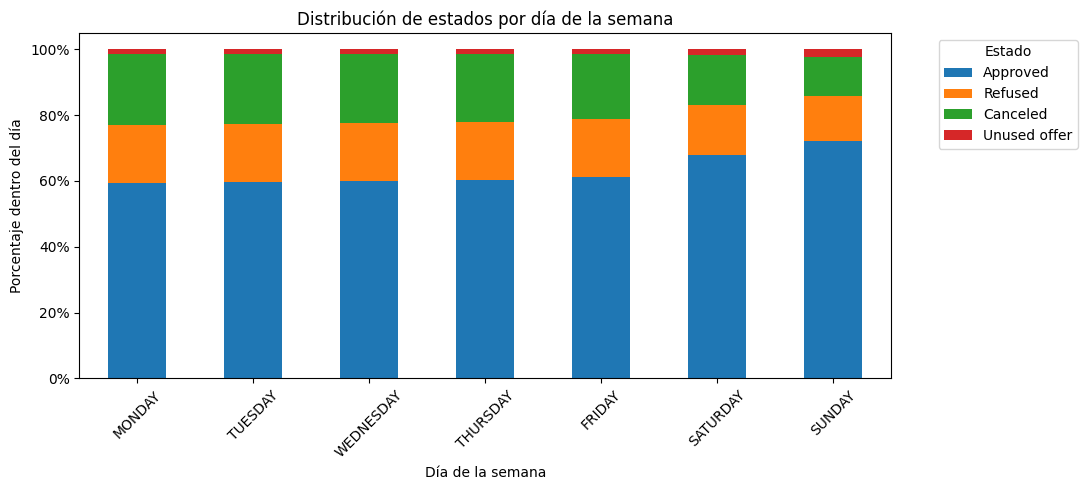

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

status_col = "NAME_CONTRACT_STATUS"
weekday_col = "WEEKDAY_APPR_PROCESS_START"
hour_col = "HOUR_APPR_PROCESS_START"

status_order = ["Approved", "Refused", "Canceled", "Unused offer"]

weekday_order = [
    "MONDAY", "TUESDAY", "WEDNESDAY", "THURSDAY",
    "FRIDAY", "SATURDAY", "SUNDAY"
]

weekday_dist = (
    pd.crosstab(
        df[weekday_col],
        df[status_col],
        normalize="index"
    )
    .reindex(weekday_order)
    .reindex(columns=status_order)
)

ax = weekday_dist.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 5)
)

plt.title("Distribución de estados por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Porcentaje dentro del día")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.legend(title="Estado", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Distribución de estados por hora del día

Se analiza la proporción de estados de solicitud para cada hora de inicio (`HOUR_APPR_PROCESS_START`). La gráfica de líneas permite comparar patrones horarios entre estados.

Las diferencias por hora pueden reflejar canales, hábitos de solicitud, operaciones comerciales o procesos de aprobación. Este análisis ayuda a decidir si vale la pena conservar variables relacionadas con el momento de la solicitud.


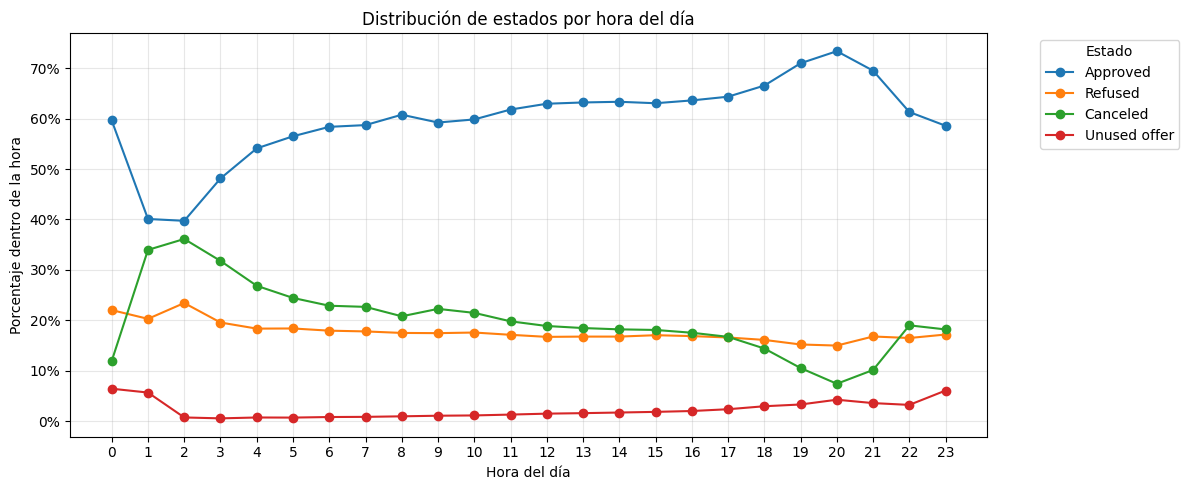

In [6]:
hour_dist = (
    pd.crosstab(
        df[hour_col],
        df[status_col],
        normalize="index"
    )
    .reindex(range(24))
    .reindex(columns=status_order)
)

ax = hour_dist.plot(
    kind="line",
    marker="o",
    figsize=(12, 5)
)

plt.title("Distribución de estados por hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Porcentaje dentro de la hora")
plt.xticks(range(24))
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.legend(title="Estado", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Análisis de motivos de rechazo

Esta sección filtra solicitudes con estado `Refused`, calcula la frecuencia de cada `CODE_REJECT_REASON` y muestra su distribución en una gráfica horizontal.

Los motivos de rechazo pueden ser más informativos que el rechazo agregado. Por ejemplo, distintos códigos pueden representar restricciones de scoring, límites, políticas internas u otras razones con implicaciones diferentes para el riesgo del cliente.


,reject_reason,count,pct
0,HC,170073,0.602658
1,LIMIT,54975,0.194805
2,SCO,37116,0.131521
3,SCOFR,12298,0.043578
4,XNA,4110,0.014564
5,VERIF,3436,0.012176
6,SYSTEM,197,0.000698


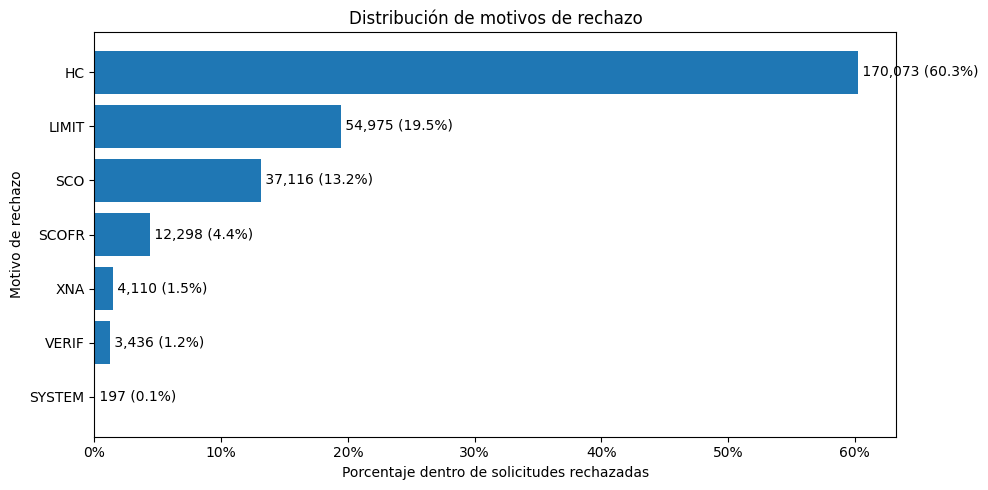

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

status_col = "NAME_CONTRACT_STATUS"
reject_col = "CODE_REJECT_REASON"

df_refused = df[df[status_col].eq("Refused")].copy()
reject_dist = (
    df_refused[reject_col]
    .value_counts(dropna=False)
    .rename_axis("reject_reason")
    .reset_index(name="count")
)

reject_dist["pct"] = reject_dist["count"] / reject_dist["count"].sum()

display(reject_dist)
reject_dist_plot = reject_dist.sort_values("pct", ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.barh(
    reject_dist_plot["reject_reason"].astype(str),
    reject_dist_plot["pct"]
)

for bar, count, pct in zip(
    bars,
    reject_dist_plot["count"],
    reject_dist_plot["pct"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {count:,} ({pct:.1%})",
        va="center"
    )

plt.title("Distribución de motivos de rechazo")
plt.xlabel("Porcentaje dentro de solicitudes rechazadas")
plt.ylabel("Motivo de rechazo")
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout()
plt.show()

## Distribución por canal de originación

Se calcula la participación de cada `CHANNEL_TYPE` dentro del dataset y se visualiza su distribución.

El canal de origen puede asociarse con distintos perfiles de clientes, productos o procesos comerciales. Conocer su distribución ayuda a interpretar sesgos de cobertura y posibles variables categóricas relevantes.


,channel_type,count,pct
0,Credit and cash offices,715930,0.431239
1,Country-wide,491987,0.296347
2,Stone,211345,0.127303
3,Regional / Local,108066,0.065093
4,Contact center,70843,0.042672
5,AP+ (Cash loan),55461,0.033407
6,Channel of corporate sales,6086,0.003666
7,Car dealer,452,0.000272


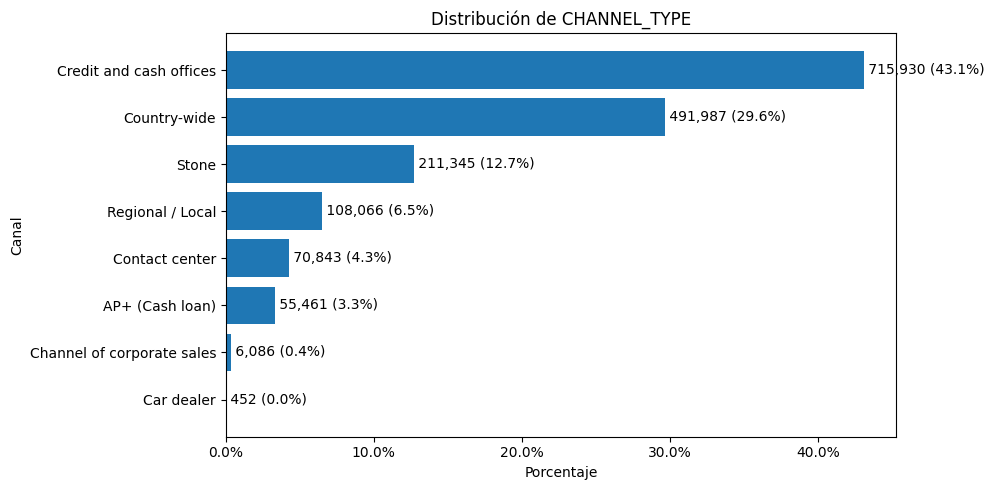

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

channel_col = "CHANNEL_TYPE"

channel_dist = (
    df[channel_col]
    .value_counts(dropna=False)
    .rename_axis("channel_type")
    .reset_index(name="count")
)

channel_dist["pct"] = channel_dist["count"] / channel_dist["count"].sum()

display(channel_dist)

channel_dist_plot = channel_dist.sort_values("pct", ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.barh(
    channel_dist_plot["channel_type"].astype(str),
    channel_dist_plot["pct"]
)

for bar, count, pct in zip(
    bars,
    channel_dist_plot["count"],
    channel_dist_plot["pct"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {count:,} ({pct:.1%})",
        va="center"
    )

plt.title("Distribución de CHANNEL_TYPE")
plt.xlabel("Porcentaje")
plt.ylabel("Canal")
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout()
plt.show()

## Construcción de features de solicitudes previas

Esta función consolida el historial de solicitudes anteriores en una fila por cliente. Las variables resultantes cubren:

- Volumen de solicitudes previas.
- Tasas de aprobación, rechazo, cancelación y oferta no usada.
- Distribución por tipo de contrato.
- Montos aprobados, solicitados y precios de bienes.
- Relación entre crédito aprobado y monto solicitado.
- Plazo del crédito (`CNT_PAYMENT`).
- Motivos de rechazo entre solicitudes rechazadas.
- Grupos de yield y uso de seguro en aprobaciones.

El historial de solicitudes previas es una fuente directa de comportamiento crediticio. Agregarlo por cliente permite alimentar modelos supervisados con variables numéricas consistentes, interpretables y trazables.


In [ ]:
import pandas as pd
import numpy as np

def build_previous_application_features(df):
    prev = df.copy()

    id_col = "SK_ID_CURR"
    status_col = "NAME_CONTRACT_STATUS"

    # BASE: UNA FILA POR SOLICITUD ACTUAL

    features = (
        prev.groupby(id_col)
            .size()
            .to_frame("prev_app_count")
    )

    # 1. ESTADOS DE SOLICITUDES PREVIAS

    features["prev_approved_rate"] = (
        prev[status_col].eq("Approved")
        .groupby(prev[id_col])
        .mean()
    )

    features["prev_refused_rate"] = (
        prev[status_col].eq("Refused")
        .groupby(prev[id_col])
        .mean()
    )

    features["prev_canceled_rate"] = (
        prev[status_col].eq("Canceled")
        .groupby(prev[id_col])
        .mean()
    )

    features["prev_unused_offer_rate"] = (
        prev[status_col].eq("Unused offer")
        .groupby(prev[id_col])
        .mean()
    )

    # 2. TIPO DE CONTRATO

    contract_type = prev["NAME_CONTRACT_TYPE"].astype(str).str.lower()

    features["prev_contract_type_cash_rate"] = (
        contract_type.str.contains("cash", na=False)
        .groupby(prev[id_col])
        .mean()
    )

    features["prev_contract_type_consumer_rate"] = (
        contract_type.str.contains("consumer", na=False)
        .groupby(prev[id_col])
        .mean()
    )

    features["prev_contract_type_revolving_rate"] = (
        contract_type.str.contains("revolving", na=False)
        .groupby(prev[id_col])
        .mean()
    )

    # 4. AMT_ANNUITY
    # Solo aprobados con anualidad positiva

    mask_annuity = (
        prev[status_col].eq("Approved") &
        prev["AMT_ANNUITY"].gt(0)
    )

    annuity_features = (
        prev.loc[mask_annuity]
        .groupby(id_col)["AMT_ANNUITY"]
        .agg(
            prev_annuity_approved_mean="mean",
            prev_annuity_approved_max="max"
        )
    )

    features = features.join(annuity_features)

    # 5. AMT_APPLICATION
    # Aprobados y rechazados con monto solicitado positivo

    mask_application = (
        prev[status_col].isin(["Approved", "Refused"]) &
        prev["AMT_APPLICATION"].gt(0)
    )

    application_features = (
        prev.loc[mask_application]
        .groupby(id_col)["AMT_APPLICATION"]
        .agg(
            prev_application_mean="mean",
            prev_application_max="max"
        )
    )

    features = features.join(application_features)

    # 6. AMT_CREDIT
    # Solo aprobados con crédito positivo

    mask_credit = (
        prev[status_col].eq("Approved") &
        prev["AMT_CREDIT"].gt(0)
    )

    credit_features = (
        prev.loc[mask_credit]
        .groupby(id_col)["AMT_CREDIT"]
        .agg(
            prev_credit_approved_mean="mean"
        )
    )

    features = features.join(credit_features)

    # Ratio AMT_CREDIT / AMT_APPLICATION en aprobados válidos
    mask_ratio = (
        prev[status_col].eq("Approved") &
        prev["AMT_CREDIT"].gt(0) &
        prev["AMT_APPLICATION"].gt(0)
    )

    ratio_df = prev.loc[
        mask_ratio,
        [id_col, "AMT_CREDIT", "AMT_APPLICATION"]
    ].copy()

    ratio_df["credit_application_ratio"] = (
        ratio_df["AMT_CREDIT"] / ratio_df["AMT_APPLICATION"]
    )

    ratio_features = (
        ratio_df.groupby(id_col)["credit_application_ratio"]
        .mean()
        .to_frame("prev_credit_application_ratio_mean")
    )

    features = features.join(ratio_features)

    # 7. AMT_GOODS_PRICE
    # Solo valores positivos

    mask_goods = prev["AMT_GOODS_PRICE"].gt(0)

    goods_features = (
        prev.loc[mask_goods]
        .groupby(id_col)["AMT_GOODS_PRICE"]
        .agg(
            prev_goods_price_mean="mean",
            prev_goods_price_max="max"
        )
    )

    features = features.join(goods_features)

    # 8. CNT_PAYMENT
    # Plazo del crédito

    mask_cnt_payment = prev["CNT_PAYMENT"].gt(0)

    cnt_payment_features = (
        prev.loc[mask_cnt_payment]
        .groupby(id_col)["CNT_PAYMENT"]
        .agg(
            prev_cnt_payment_mean="mean",
            prev_cnt_payment_max="max"
        )
    )

    features = features.join(cnt_payment_features)

    # 9. CODE_REJECT_REASON
    # Tasas entre solicitudes rechazadas

    refused_mask = prev[status_col].eq("Refused")
    refused_total = refused_mask.groupby(prev[id_col]).sum()

    reject_reason = prev["CODE_REJECT_REASON"].astype(str).str.upper()

    features["prev_reject_hc_rate"] = (
        (refused_mask & reject_reason.eq("HC"))
        .groupby(prev[id_col])
        .sum()
        .div(refused_total.replace(0, np.nan))
    )

    features["prev_reject_limit_rate"] = (
        (refused_mask & reject_reason.eq("LIMIT"))
        .groupby(prev[id_col])
        .sum()
        .div(refused_total.replace(0, np.nan))
    )

    features["prev_reject_sco_rate"] = (
        (refused_mask & reject_reason.eq("SCO"))
        .groupby(prev[id_col])
        .sum()
        .div(refused_total.replace(0, np.nan))
    )

    # 10. NAME_YIELD_GROUP
    # Tasas de yield alto y bajo

    yield_group = prev["NAME_YIELD_GROUP"].astype(str).str.lower()

    features["prev_yield_high_rate"] = (
        yield_group.eq("high")
        .groupby(prev[id_col])
        .mean()
    )

    features["prev_yield_low_rate"] = (
        yield_group.str.contains("low", na=False)
        .groupby(prev[id_col])
        .mean()
    )

    # 11. NFLAG_INSURED_ON_APPROVAL
    # Seguro en créditos aprobados

    approved_mask = prev[status_col].eq("Approved")
    approved_total = approved_mask.groupby(prev[id_col]).sum()

    insured = (
        pd.to_numeric(prev["NFLAG_INSURED_ON_APPROVAL"], errors="coerce")
        .fillna(0)
        .eq(1)
    )

    features["prev_insured_on_approval_count"] = (
        (approved_mask & insured)
        .groupby(prev[id_col])
        .sum()
    )

    features["prev_insured_on_approval_rate"] = (
        features["prev_insured_on_approval_count"]
        .div(approved_total.replace(0, np.nan))
    )

    # ORDEN FINAL

    final_cols = [
        "prev_app_count",

        "prev_approved_rate",
        "prev_refused_rate",
        "prev_canceled_rate",
        "prev_unused_offer_rate",

        "prev_contract_type_cash_rate",
        "prev_contract_type_consumer_rate",
        "prev_contract_type_revolving_rate",

        "prev_annuity_approved_mean",
        "prev_annuity_approved_max",

        "prev_application_mean",
        "prev_application_max",

        "prev_credit_approved_mean",
        "prev_credit_application_ratio_mean",

        "prev_goods_price_mean",
        "prev_goods_price_max",

        "prev_cnt_payment_mean",
        "prev_cnt_payment_max",

        "prev_reject_hc_rate",
        "prev_reject_limit_rate",
        "prev_reject_sco_rate",

        "prev_yield_high_rate",
        "prev_yield_low_rate",

        "prev_insured_on_approval_rate",
        "prev_insured_on_approval_count"
    ]

    features = (
        features
        .reindex(columns=final_cols)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
        .reset_index()
    )

    return features


prev_features = build_previous_application_features(df)

display(prev_features.head())
print(prev_features.shape)

,SK_ID_CURR,prev_app_count,prev_approved_rate,prev_refused_rate,prev_canceled_rate,prev_unused_offer_rate,prev_contract_type_cash_rate,prev_contract_type_consumer_rate,prev_contract_type_revolving_rate,prev_annuity_approved_mean,...,prev_goods_price_max,prev_cnt_payment_mean,prev_cnt_payment_max,prev_reject_hc_rate,prev_reject_limit_rate,prev_reject_sco_rate,prev_yield_high_rate,prev_yield_low_rate,prev_insured_on_approval_rate,prev_insured_on_approval_count
0,100001,1,1.0,0.0,0.0,0.0,0.000000,1.000000,0.0,3951.000,...,24835.5,8.0,8.0,0.0,0.0,0.0,1.0,0.000000,0.000000,0
1,100002,1,1.0,0.0,0.0,0.0,0.000000,1.000000,0.0,9251.775,...,179055.0,24.0,24.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0
2,100003,3,1.0,0.0,0.0,0.0,0.333333,0.666667,0.0,56553.990,...,900000.0,10.0,12.0,0.0,0.0,0.0,0.0,0.333333,0.666667,2
3,100004,1,1.0,0.0,0.0,0.0,0.000000,1.000000,0.0,5357.250,...,24282.0,4.0,4.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0
4,100005,2,0.5,0.0,0.5,0.0,0.500000,0.500000,0.0,4813.200,...,44617.5,12.0,12.0,0.0,0.0,0.0,0.5,0.000000,0.000000,0


(338854, 26)
